# Assignment-9: K-Means Clustering

**Objective:** Apply K-Means clustering on a dataset, understand cluster formation, and visualize results.

---

## Q1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
print('Libraries imported')

Libraries imported


###  Load Iris Dataset (features only — unlabeled)

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df = df.drop(columns=['target'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Q2: Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.describe()

Shape: (150, 4)

Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Q3: Select Features for Clustering (Two Features for Visualization)

In [4]:
X = df[['sepal length (cm)', 'sepal width (cm)']]
X.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


## Q4: Visualize Raw Data (Scatter Plot)

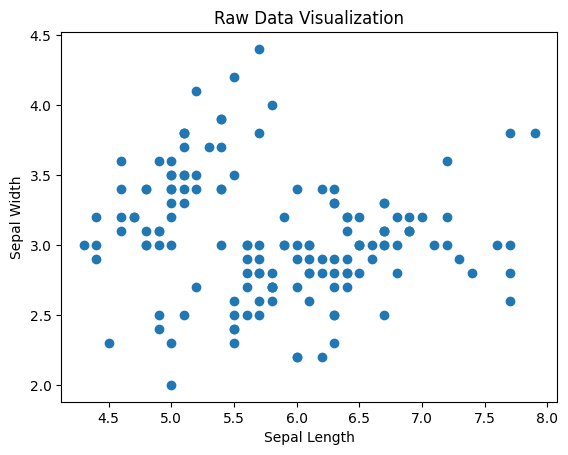

In [5]:
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Raw Data Visualization')
plt.show()

## Q5: Apply K-Means Algorithm (K = 3)

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
print('Model trained')

Model trained


## Q6: Assign Cluster Labels to Dataset

In [7]:
X_clustered = X.copy()
X_clustered['Cluster'] = kmeans.labels_
X_clustered.head()

,sepal length (cm),sepal width (cm),Cluster
0,5.1,3.5,2
1,4.9,3.0,2
2,4.7,3.2,2
3,4.6,3.1,2
4,5.0,3.6,2


## Q7: Elbow Method to Find Best K

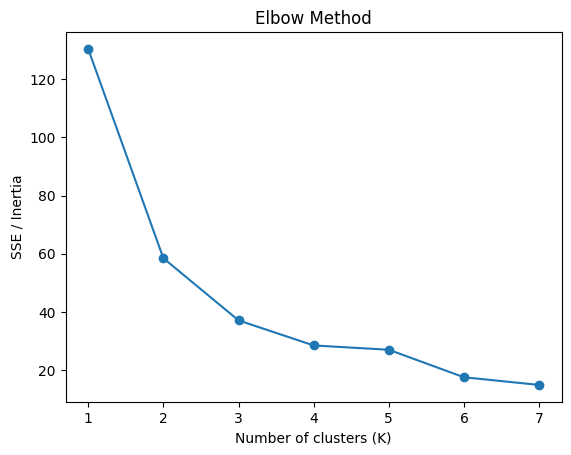

In [8]:
sse = []
K = range(1, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    sse.append(km.inertia_)

plt.plot(K, sse, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method')
plt.show()

## Q8: Visualize Final Clusters with Centroids

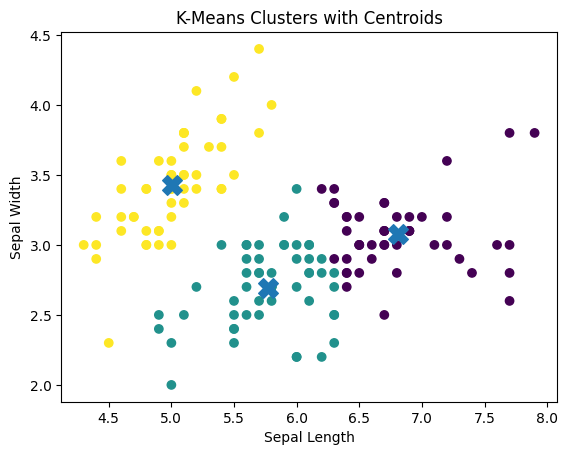

In [9]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=kmeans.labels_)
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clusters with Centroids')
plt.show()

## Q9: Interpret Clustering Results

### Interpretation of Clustering Results

Based on the K-Means clustering applied to the Iris dataset (using 'sepal length (cm)' and 'sepal width (cm)' as features):

-   **Number of Clusters Formed:** From the elbow method plot (Q7), the 'elbow' appears to be around K=3, which suggests that 3 is an optimal number of clusters for this dataset based on these features. The K-Means algorithm was then run with `n_clusters=3`.

-   **How Points are Grouped:** The visualization in Q8 shows three distinct groups of data points.
    -   One cluster (e.g., the purple one) is characterized by generally smaller sepal lengths and larger sepal widths, forming a relatively tight group.
    -   Another cluster (e.g., the yellow one) has intermediate sepal lengths and sepal widths, with a somewhat elongated shape.
    -   The third cluster (e.g., the green one) is characterized by larger sepal lengths and intermediate sepal widths, also forming a somewhat elongated group.

-   **Differences Between Clusters:**
    -   **Cluster 1 (Centroid approximately at [6.81, 3.07]):** This cluster generally represents flowers with longer sepal lengths and average sepal widths.
    -   **Cluster 2 (Centroid approximately at [5.77, 2.69]):** This cluster contains flowers with average sepal lengths and smaller sepal widths.
    -   **Cluster 3 (Centroid approximately at [5.01, 3.43]):** This cluster groups flowers with shorter sepal lengths and larger sepal widths.

The clusters demonstrate a clear separation, particularly between the cluster with smaller sepal lengths/larger sepal widths and the other two. The other two clusters (with larger sepal lengths) show some overlap, indicating that using only these two features might not perfectly separate all original species, but still reveal meaningful structures in the data.

## Q10: Conclusion (Write in your own words)

### Conclusion

**How K-Means Works:**
K-Means is an unsupervised machine learning algorithm used for partitioning a dataset into K distinct, non-overlapping subgroups (clusters). The algorithm iteratively performs two main steps:
1.  **Centroid Initialization:** It starts by randomly selecting K data points as initial centroids.
2.  **Assignment and Update:**
    *   Each data point is assigned to the cluster whose centroid is closest to it (e.g., based on Euclidean distance).
    *   The centroids are then re-calculated as the mean of all data points assigned to that cluster.
These steps are repeated until the centroids no longer change significantly or a maximum number of iterations is reached, meaning the clusters have stabilized.

**Usefulness of Clustering:**
Clustering is a powerful technique with numerous applications:
*   **Data Exploration and Understanding:** It helps discover natural groupings within data, revealing underlying structures and patterns that might not be obvious otherwise.
*   **Customer Segmentation:** Businesses use it to group customers with similar behaviors or demographics for targeted marketing.
*   **Anomaly Detection:** Outliers that do not fit well into any cluster can be identified as potential anomalies or fraud.
*   **Image Segmentation:** Grouping pixels with similar characteristics to identify objects or regions in an image.
*   **Document Analysis:** Categorizing documents into themes or topics.

**Observations from this Experiment:**
In this experiment using the Iris dataset with 'sepal length (cm)' and 'sepal width (cm)' as features, we observed the following:
*   **Optimal K:** The Elbow Method suggested that `K=3` was an optimal number of clusters for this particular feature set, as the decrease in SSE (Sum of Squared Errors) started to level off around this point.
*   **Cluster Separation:** The K-Means algorithm effectively partitioned the data into three visually distinct clusters. One cluster predominantly consisted of data points with smaller sepal lengths and larger sepal widths, indicating a clear group. The other two clusters, while distinct, showed some degree of overlap, suggesting that while 'sepal length' and 'sepal width' are useful, they might not fully differentiate all natural groupings within the Iris species without additional features.
*   **Centroids:** The calculated centroids provided a representative 'center' for each cluster, helping to characterize the typical 'sepal length' and 'sepal width' values for the data points within that cluster.